# Frustum POC — YOLO 2D + LiDAR depth vs the keyframe 3D boxes

Visualizes `data/processed/frustum_poc_report.json` from `scripts/frustum_poc.py`, and
compares it head-to-head with the PointPillars 3D gate (`detector_recall_report.json`).

**Pipeline:** YOLO detects pedestrians in the keyframe image → the keyframe LiDAR scan is
projected into the image → points inside each 2D box (the frustum) are reduced to a 3D
centre via a nearest-depth slab → matched to the verified `location_3d` boxes by BEV centre
distance (the **same** 2 m gate as the PointPillars eval, on the **same** 1,830 GT boxes).

The headline new number is the **localization error**: how close the lifted 3D centres are
to the annotated box centres — i.e. whether 2D+LiDAR yields *usable* 3D positions.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
report = json.loads((PROC / "frustum_poc_report.json").read_text())
cfg, overall = report["config"], report["overall"]
# PointPillars 3D gate, for comparison (optional).
pp = None
pp_path = PROC / "detector_recall_report.json"
if pp_path.exists():
    pp = json.loads(pp_path.read_text())
print("frustum cfg:", {k: cfg[k] for k in ("model", "imgsz", "conf", "match_dist_m", "box_shrink", "slab_m")})
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

frustum cfg: {'model': 'yolo11x.pt', 'imgsz': 2560, 'conf': 0.1, 'match_dist_m': 2.0, 'box_shrink': 0.6, 'slab_m': 1.5}


## 1. Frustum vs PointPillars (same GT, same match gate)

FRUSTUM   recall=0.585  precision=0.533  (TP=1071 FN=759 FP=938, GT=1830)
POINTPLR  recall=0.485  precision=0.085  (TP=888 FN=942 FP=9598, GT=1830)


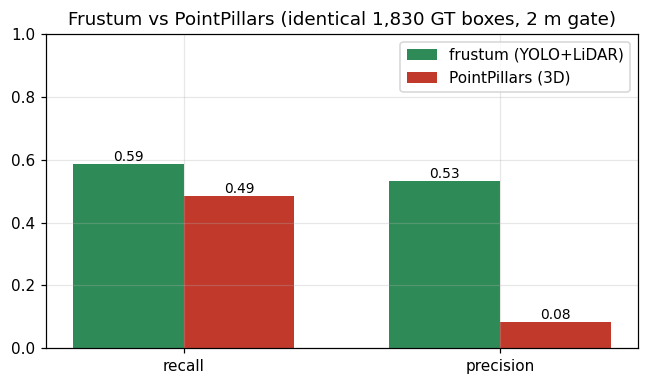

In [2]:
o = overall
print(f"FRUSTUM   recall={o['recall']:.3f}  precision={o['precision']:.3f}  "
      f"(TP={o['tp']} FN={o['fn']} FP={o['fp']}, GT={o['n_gt']})")
if pp:
    po = pp["overall"]
    print(f"POINTPLR  recall={po['recall']:.3f}  precision={po['precision']:.3f}  "
          f"(TP={po['tp']} FN={po['fn']} FP={po['fp']}, GT={po['n_gt']})")

if pp:
    fig, ax = plt.subplots(figsize=(6, 3.6))
    x = np.arange(2); w = 0.35
    ax.bar(x - w/2, [o["recall"], o["precision"]], w, label="frustum (YOLO+LiDAR)", color="#2e8b57")
    ax.bar(x + w/2, [pp["overall"]["recall"], pp["overall"]["precision"]], w,
           label="PointPillars (3D)", color="#c0392b")
    ax.set_xticks(x); ax.set_xticklabels(["recall", "precision"]); ax.set_ylim(0, 1.0)
    for i, (a, b) in enumerate([(o["recall"], pp["overall"]["recall"]),
                                (o["precision"], pp["overall"]["precision"])]):
        ax.text(i - w/2, a + 0.01, f"{a:.2f}", ha="center", fontsize=9)
        ax.text(i + w/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=9)
    ax.set_title("Frustum vs PointPillars (identical 1,830 GT boxes, 2 m gate)"); ax.legend()
    plt.tight_layout(); plt.show()

## 2. Localization error — are the 3D positions usable?

BEV distance between each lifted 3D centre and its matched GT box centre. A median around
0.2 m is partly **systematic surface bias** (LiDAR hits the body surface facing the sensor,
~half a body-depth in front of the box centre) — so it is correctable, not noise.

matched pairs: 1071 | median 0.147 m | mean 0.254 m | p90 0.515 m


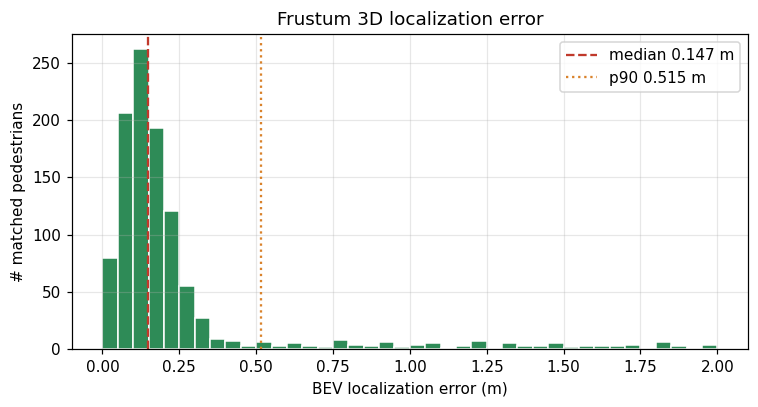

In [3]:
le = report["localization_error_m"]
err = np.array(le.get("errors", []))
print(f"matched pairs: {le['n_matched']} | median {le['median']} m | mean {le['mean']} m | p90 {le['p90']} m")
if err.size:
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.hist(err, bins=np.linspace(0, max(2.0, err.max()), 41), color="#2e8b57", edgecolor="white")
    ax.axvline(le["median"], color="#c0392b", ls="--", label=f"median {le['median']} m")
    ax.axvline(le["p90"], color="#d9822b", ls=":", label=f"p90 {le['p90']} m")
    ax.set_xlabel("BEV localization error (m)"); ax.set_ylabel("# matched pedestrians")
    ax.set_title("Frustum 3D localization error"); ax.legend()
    plt.tight_layout(); plt.show()

## 3. Recall by range and point sparsity (vs PointPillars)

Frustum recall is bounded by YOLO's 2D recall *and* by having enough LiDAR points in the
box to get depth — so it falls off on sparse/distant pedestrians, but stays well above
PointPillars at every range.

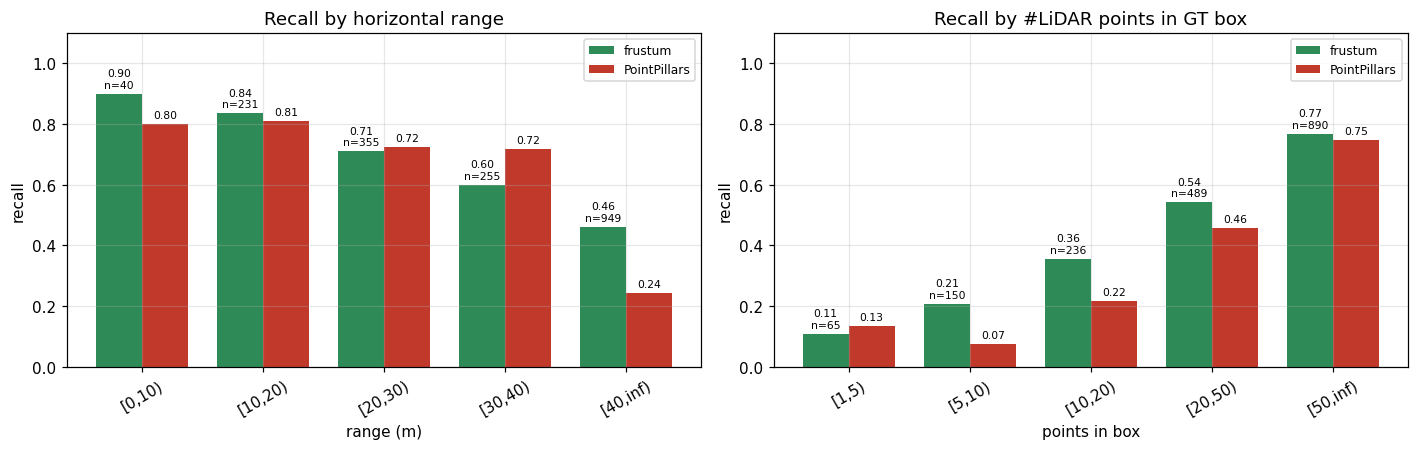

In [4]:
def overlay(ax, key, title, xlabel):
    bins = report[key]
    labels = [b["bin"] for b in bins]
    fr = [b["recall"] if b["recall"] is not None else 0.0 for b in bins]
    x = np.arange(len(labels)); w = 0.38
    ax.bar(x - w/2, fr, w, label="frustum", color="#2e8b57")
    for xi, r, n in zip(x, fr, [b["n_gt"] for b in bins]):
        ax.text(xi - w/2, r + 0.02, f"{r:.2f}\nn={n}", ha="center", fontsize=7)
    if pp and key in pp:
        pr = [b["recall"] if b["recall"] is not None else 0.0 for b in pp[key]]
        if len(pr) == len(labels):
            ax.bar(x + w/2, pr, w, label="PointPillars", color="#c0392b")
            for xi, r in zip(x, pr):
                ax.text(xi + w/2, r + 0.02, f"{r:.2f}", ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30); ax.set_ylim(0, 1.1)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("recall"); ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
overlay(axes[0], "by_range_xy_m", "Recall by horizontal range", "range (m)")
overlay(axes[1], "by_lidar_points", "Recall by #LiDAR points in GT box", "points in box")
plt.tight_layout(); plt.show()

## 4. Visual: 2D box + frustum points (image) and lifted 3D vs GT (BEV)

For a few sequences, left = keyframe image with YOLO boxes and the LiDAR points that
project inside them (orange = points used for the lift); right = BEV with the lifted 3D
centres (blue +) against the GT boxes (green = matched, red = missed).

> Requires `ultralytics`. If unavailable, this section is skipped.

In [5]:
import sys
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

FR = None
try:
    from eval_detector2d_recall import make_yolo
    from frustum_poc import lift_box_to_3d, match_greedy_3d, Frustum3D
    from dataset.keyframe import (keyframe_image_path, load_keyframe_pedestrians,
                                  nearest_lidar_scan, load_xyzi, parse_zod_ts, MAX_LIDAR_GAP_S,
                                  motion_compensate_to_keyframe, lidar_ts_from_filename)
    from utils.projection import load_calibration, project_lidar_to_image
    FR = make_yolo(cfg["model"], conf=cfg["conf"], imgsz=cfg["imgsz"])
    print("frustum pipeline ready")
except Exception as e:
    print("unavailable -> skipping visual section:", repr(e)[:160])

frustum pipeline ready


visualizing: ['000046', '000048', '000049', '001065', '001119', '001122']


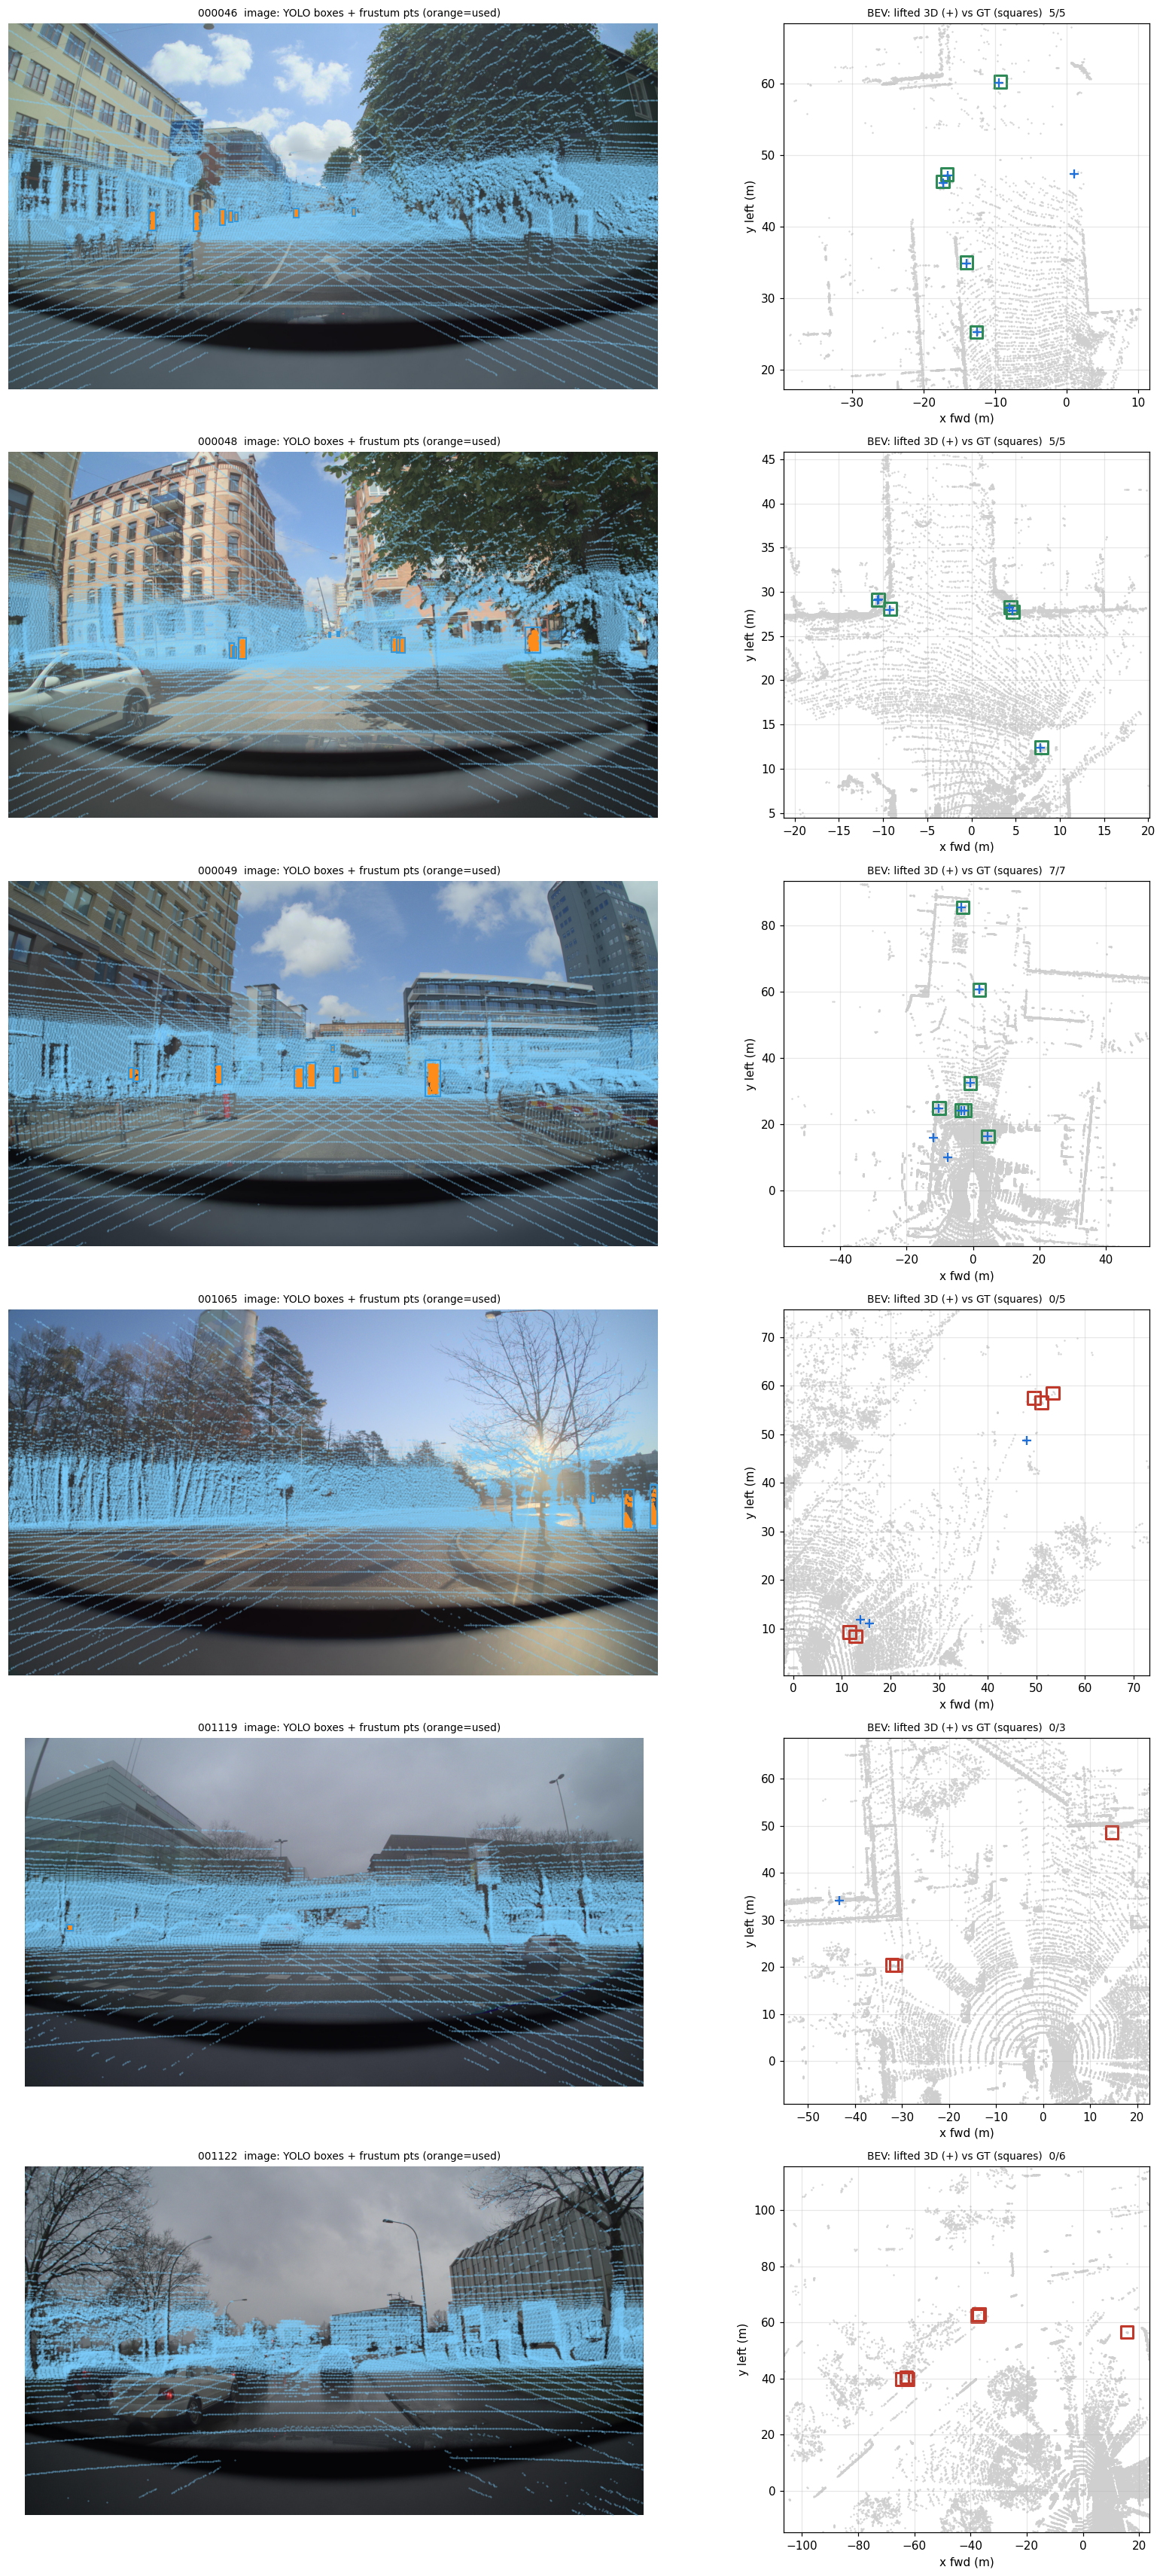

In [6]:
from matplotlib.patches import Rectangle
from PIL import Image

SEQ_DIR = ROOT / "data" / "raw" / "sequences"

def show_pair(ax_img, ax_bev, seq_id):
    sd = SEQ_DIR / seq_id
    img_path, _ = keyframe_image_path(sd)
    kts = parse_zod_ts(json.loads((sd / "info.json").read_text())["keyframe_time"])
    scan, gap = nearest_lidar_scan(sd / "lidar_velodyne", kts)
    calib = load_calibration(sd / "calibration.json")
    gts = load_keyframe_pedestrians(sd)
    # compensate the +37ms scan to the keyframe instant (matches frustum_poc + the report)
    pts = motion_compensate_to_keyframe(load_xyzi(scan), sd, lidar_ts_from_filename(scan.name), kts)[:, :3]
    uv, valid = project_lidar_to_image(pts, calib)
    pts_vis = pts[valid]
    boxes = FR(img_path)

    dets, used_masks = [], []
    for b in boxes:
        x1, y1, x2, y2 = b.xyxy
        cx = 0.5 * (x1 + x2); hw = 0.5 * (x2 - x1) * cfg["box_shrink"]
        y_lo, y_hi = y1 + 0.10 * (y2 - y1), y1 + 0.90 * (y2 - y1)
        inb = (uv[:, 0] >= cx - hw) & (uv[:, 0] <= cx + hw) & (uv[:, 1] >= y_lo) & (uv[:, 1] <= y_hi)
        used_masks.append(inb)
        est = lift_box_to_3d(b.xyxy, uv, pts_vis, cfg["box_shrink"], cfg["slab_m"], cfg["min_pts"])
        if est is not None:
            dets.append(Frustum3D(center=est[0], score=b.score, n_points=est[1]))
    matched, _ = match_greedy_3d(dets, gts, cfg["match_dist_m"])

    # left: image with boxes + frustum points
    ax_img.imshow(np.array(Image.open(img_path)))
    ax_img.scatter(uv[:, 0], uv[:, 1], s=0.2, c="#7fd0ff", alpha=0.4)
    any_used = np.any(used_masks, axis=0) if used_masks else np.zeros(len(uv), bool)
    ax_img.scatter(uv[any_used, 0], uv[any_used, 1], s=0.6, c="#ff8c1a")
    for b in boxes:
        x1, y1, x2, y2 = b.xyxy
        ax_img.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#3498db", lw=1.4))
    ax_img.set_title(f"{seq_id}  image: YOLO boxes + frustum pts (orange=used)", fontsize=9)
    ax_img.axis("off")

    # right: BEV — GT boxes (green/red) + lifted centres (blue +)
    focus = [g.center[:2] for g in gts] or [d.center[:2] for d in dets] or [np.zeros(2)]
    C = np.asarray(focus, float); cx0, cy0 = C[:, 0].mean(), C[:, 1].mean()
    half = max(18.0, float(np.abs(C - [cx0, cy0]).max()) + 8.0)
    m = (np.abs(pts[:, 0] - cx0) <= half) & (np.abs(pts[:, 1] - cy0) <= half)
    p = pts[m]
    ax_bev.scatter(p[::3, 0], p[::3, 1], s=0.3, c="#cfcfcf")
    for g, hit in zip(gts, matched):
        col = "#2e8b57" if hit else "#c0392b"
        ax_bev.scatter(g.center[0], g.center[1], marker="s", facecolors="none", edgecolors=col, s=120, lw=2)
    for d in dets:
        ax_bev.scatter(d.center[0], d.center[1], marker="+", c="#1f6fdb", s=70, zorder=5)
    ax_bev.set_xlim(cx0 - half, cx0 + half); ax_bev.set_ylim(cy0 - half, cy0 + half)
    ax_bev.set_aspect("equal"); ax_bev.set_xlabel("x fwd (m)"); ax_bev.set_ylabel("y left (m)")
    ax_bev.set_title(f"BEV: lifted 3D (+) vs GT (squares)  {sum(matched)}/{len(gts)}", fontsize=9)

if FR is not None:
    scored = sorted([s for s in report["per_sequence"]
                     if s.get("recall") is not None and s["n_gt"] >= 3], key=lambda s: -s["recall"])
    # GOOD (top, lift working) + BAD (bottom, where it fails) scenes
    seqs = [s["seq_id"] for s in scored[:3]] + [s["seq_id"] for s in scored[-3:]]
    # seqs = ["000007"]   # <- edit to inspect specific sequences
    print("visualizing:", seqs)
    fig, axes = plt.subplots(len(seqs), 2, figsize=(15, 5.2 * len(seqs)),
                             gridspec_kw={"width_ratios": [2, 1]})
    axes = np.atleast_2d(axes)
    for i, sq in enumerate(seqs):
        show_pair(axes[i][0], axes[i][1], sq)
    plt.tight_layout(); plt.show()

**Reading the panels:** on the left, orange points are the LiDAR returns that fed each
3D estimate — you can see them land on the pedestrians' bodies. On the right, a blue **+**
sitting inside a green square is a correctly-lifted pedestrian; the small, consistent
offset toward the ego (origin) is the surface bias noted in section 2. Red squares with no
nearby **+** are pedestrians YOLO missed or that had too few LiDAR points to lift.

Next steps under consideration: half-depth bias correction, a conf/precision sweep, and
wiring these frustum measurements into the KF/RTS linker in `src/labeling/tracker.py`.